In [1]:
# import packages
%matplotlib inline
import numpy as np
import math
import sys
# sys.path.append('.')  # or full path to CompSep
np.math = math  # Redirect numpy.math to the built-in math module
import torch
import denoising
import importlib
denoising = importlib.reload(denoising)
import utils
utils = importlib.reload(utils)
import matplotlib.pyplot as plt
from scipy.signal import windows

The general problem we face is to recover a set of signals  
$\{ s_1, \ldots, s_M \}$, given observations

$$
d_i = \mathcal{F}_i[s_1, \ldots, s_M],
$$
for $i=1...N$

The forward model may be complex and can include stochastic components (e.g. instrumental noise) as well as masking operations.  

As a simplified case, in this notebook we consider two fields and two data points:

$$
\begin{aligned}
d_1 &= s_1 + c^0_1, \\
d_2 &= s_2 + c^0_2.
\end{aligned}
$$
The superscript $0$ refers to the true noise configuration. The whole methodology rests upon the fact that we can calculate $\mathcal{F}$, and in this case it merely amounts to being able to sample the distributions of $c^0_1$ and $c^0_2$.

In [13]:
# Load the column density map from file
logN_H = np.load('Archive/Turb_3.npy')[1]  
# logN_H = utils.downsample_by_four(logN_H)
nx, ny = logN_H.shape

dx, dy = nx // 4, ny // 4
logN_H = logN_H[nx//2 - dx : nx//2 + dx, ny//2 - dy : ny//2 + dy]

# Define constant dust temperature
T_d = 10  # Typical Planck dust temperature in K

# int_val = []
# for nu in nu_list:
#     int_val.append(np.mean(modified_blackbody(logN_H, T_d, nu*1e9)))
# int_val = np.array(int_val)

# Observation frequency (e.g., 353 GHz in Hz)

# Compute the mock observed intensity map in μK_CMB
nu = (217,353)
# I_nu_map_μK_nu1 = utils.modified_blackbody(logN_H, T_d, nu[0]*1e9)
# I_nu_map_μK_nu2 = utils.modified_blackbody(logN_H, T_d, nu[1]*1e9)
alpha_1 = utils.MBB_factor(T_d, nu[0]*1e9)
alpha_2 = utils.MBB_factor(T_d, nu[1]*1e9)
I_nu_map_μK_nu1 = 10**logN_H*alpha_1
I_nu_map_μK_nu2 = 10**logN_H*alpha_2

I_nu_map_μK = (I_nu_map_μK_nu1, I_nu_map_μK_nu2)

Here we define our contamination arrays

In [3]:
#Compute linear scale of images
M,N = I_nu_map_μK_nu1.shape
#Compute maximum diadic scale for computation
J = int(np.log2(M)) - 1

# Ensure inputs have shape (1, M, N)
dust_nu1 = I_nu_map_μK_nu1[None, :, :]
dust_nu2 = I_nu_map_μK_nu2[None, :, :]

dust = (dust_nu1, dust_nu2)

# --- noise Parameters ---
n_realizations = 100
SNR = 2
nx, ny = dust_nu1.shape[-2], dust_nu1.shape[-1]

variance_nu1 = (np.std(dust_nu1) / SNR) ** 2
variance_nu2 = (np.std(dust_nu2) / SNR) ** 2
variance = (variance_nu1, variance_nu2)

# --- Create contamination_arr with shape (n_realizations, 2, 1, H, W) ---
contamination_arr = np.zeros((n_realizations, 2, 1, nx, ny), dtype=np.float32)

for i in range(n_realizations):
    # Independent noise: shape (1, H, W)
    noise_nu1 = np.random.normal(0, np.sqrt(variance_nu1), (1, nx, ny)) 
    noise_nu2 = np.random.normal(0, np.sqrt(variance_nu2), (1, nx, ny))

    # Total contamination: shape (1, H, W)
    contamination_arr[i, 0] = noise_nu1 
    contamination_arr[i, 1] = noise_nu2

contamination_arr_nu1 = contamination_arr[:, 0]  # shape: (Mn, 1, H, W)
contamination_arr_nu2 = contamination_arr[:, 1]  # shape: (Mn, 1, H, W)


Here our data is defined. For this toy model, we just take a rigidly scaled dust map at two different frequencies (so the problem is actually the same twice modulo a multiplicative factor, but it's only for illustration)

In [4]:
noise_nu1 = np.random.normal(0, np.sqrt(variance_nu1), dust_nu1.shape)
noise_nu2 = np.random.normal(0, np.sqrt(variance_nu2), dust_nu2.shape)

noise = (noise_nu1, noise_nu2)

data_nu1 = dust_nu1 + noise_nu1
data_nu2 = dust_nu2 + noise_nu2

# define target
data = (data_nu1, data_nu2)
data = tuple(img for img in data)

Definition of initial map in GD, as well as the target map

In [5]:
# definte initial maps for optimisation
image_target = data
image_init = image_target

threshold_func is True if want to threshold the statistics, else we get the full set.

remove_edge is True if the edge is removed for applications without periodic boundaries

Crucially, we compute a dictionary called std. This computes the standard deviation of $\phi(x + c)$ with respect to c. $x$ here is some map.

Notice that I compute a set of stds for each different loss that I am imposing.

In [25]:
threshold_func = None
remove_edge = False

std = {
    'single': denoising.compute_std(image_target, contamination_arr=contamination_arr,
                                    s_cov_func=threshold_func, remove_edge=remove_edge, precision='double'),
                                    
    'noise_mean_std': denoising.noise_mean_std(contamination_arr, remove_edge=remove_edge, precision='double')
}

Here we call the "denoise" function, which is the part that does the GD

In [ ]:
image_init = image_target

n_epochs = 2 #number of epochs
# decontaminate
for i in range(n_epochs):
    print(f'Starting epoch {i+1}')
    running_map = denoising.denoise(image_target, contamination_arr = contamination_arr, std = std, seed=0, print_each_step=True, 
                                    steps = 20, n_batch = 25, s_cov_func=threshold_func, image_init = image_init, remove_edge=remove_edge, precision='single', 
                                    if_large_batch=False, epochNo = i)
    running_map = (running_map[0], running_map[1])
    image_init = running_map

    if i % 2 == 1:
        std = {
        'single': denoising.compute_std(running_map, contamination_arr=contamination_arr,
                                        s_cov_func=threshold_func, remove_edge=remove_edge, precision='single'),

        'noise_mean_std': std['noise_mean_std']
    }
        
    # image_init = image_target
print('done')


Starting epoch 1
Current Loss: 8.56e+00
Current Loss: 8.60e+00
Current Loss: 8.64e+00
Current Loss: 8.61e+00
Current Loss: 8.53e+00
Current Loss: 7.04e+00
Current Loss: 6.13e+00
Current Loss: 5.15e+00
Current Loss: 4.36e+00
Current Loss: 3.64e+00
Current Loss: 3.21e+00
Current Loss: 2.73e+00
Current Loss: 2.46e+00
Current Loss: 2.25e+00
Current Loss: 2.04e+00
Current Loss: 1.95e+00
Current Loss: 1.80e+00
Current Loss: 1.74e+00
Current Loss: 1.67e+00
Current Loss: 1.65e+00
Time used:  46.92718505859375 s
Starting epoch 2
Current Loss: 8.56e+00
Current Loss: 8.60e+00
Current Loss: 8.64e+00
Current Loss: 8.61e+00
Current Loss: 8.53e+00
Current Loss: 7.04e+00
Current Loss: 6.13e+00
Current Loss: 5.15e+00
Current Loss: 4.36e+00
Current Loss: 3.64e+00
Current Loss: 3.21e+00
Current Loss: 2.73e+00
Current Loss: 2.46e+00
Current Loss: 2.25e+00
Current Loss: 2.04e+00
Current Loss: 1.95e+00
Current Loss: 1.80e+00
Current Loss: 1.74e+00
Current Loss: 1.67e+00
Current Loss: 1.65e+00
Time used:  46

In [8]:
lam = 0.55
result_nu1 = denoising.filter_radial(np.array([running_map[0]]), lambda k: k < nx * lam)[0]
result_nu2 = denoising.filter_radial(np.array([running_map[1]]), lambda k: k < nx * lam)[0]
result = (result_nu1, result_nu2)

In [37]:
def plot_2maps(map1, map2, titles, cmap='magma', savepath=None, vmin=None, vmax=None):
    """
    Plot three 2D maps side by side with a shared color scale and colorbar.

    Parameters
    ----------
    map1, map2, map3 : np.ndarray
        2D arrays to display.
    titles : tuple of str
        Titles for the three panels.
    cmap : str, optional
        Colormap for all plots (default 'inferno').
    savepath : str or None, optional
        If provided, saves the figure to this path.
    """

    # Determine symmetric color range if not provided
    if vmin is None and vmax is None:
        vmax = np.max([
            np.abs(map1).max(),
            np.abs(map2).max()
        ])
        vmin = -vmax

    fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)

    im = None
    for ax, m, title in zip(axes, [map1, map2], titles):
        im = ax.imshow(m, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=20)
        ax.axis('off')

    # Shared colorbar
    cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)

    if savepath is not None:
        plt.savefig(savepath, dpi=300, transparent=True)

    plt.show()

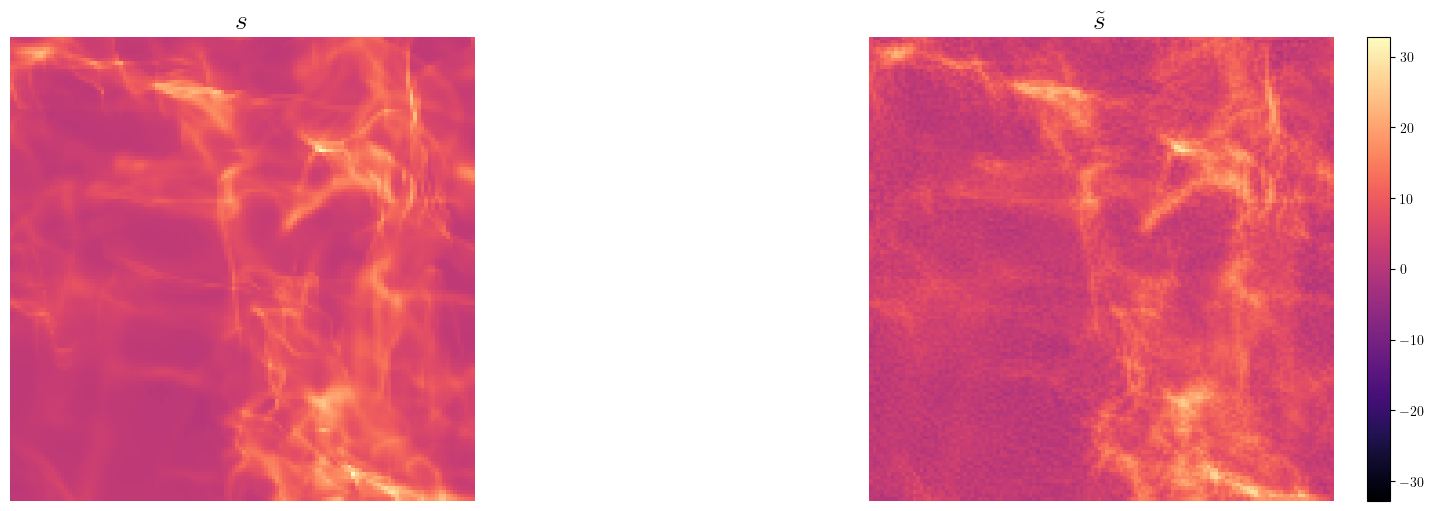

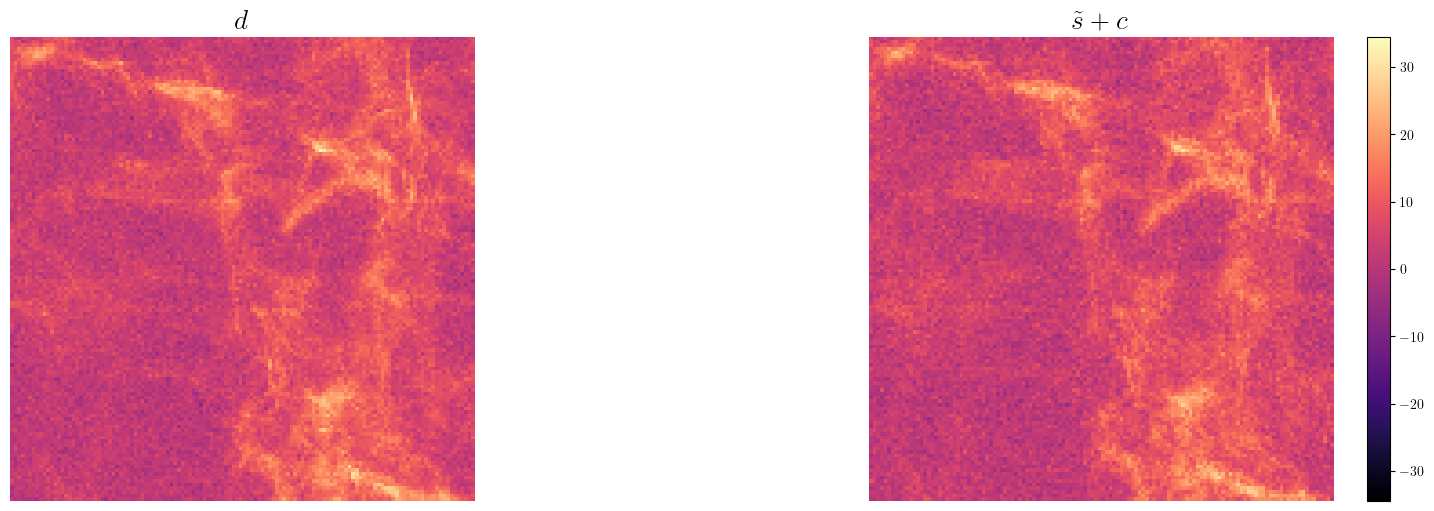

In [42]:
# Enable LaTeX rendering
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
x1, x2  = dust_nu2[0], result_nu2[0]
titles=(r'$s$', r'$\tilde{s}$')
plot_2maps(x1, x2, titles)

x1, x2  = data_nu2[0], result_nu2[0] +contamination_arr_nu2.squeeze()[0]
titles=(r'$d$', r'$\tilde{s} + c$')
plot_2maps(x1, x2, titles)

In [43]:
def plot_PS(
    fields,
    titles=None,
    dx=None,
    k_max=None,
    window=True,
    fname=None,
):
    """
    Plot power spectra P(k) of a list of 2D or 3D fields on log-log axes.

    Parameters
    ----------
    fields : list of np.ndarray
        Each element is either:
        - 2D array (ny, nx): a single map
        - 3D array (N, ny, nx): a stack of N maps; we plot mean ± 1σ envelope.
        All maps must share the same (ny, nx).
    titles : list of str, optional
        Labels for each spectrum (for legend).
    dx : float, optional
        Pixel size (e.g. arcmin) passed to utils.power_spectrum.
    k_max : float, optional
        If given, crop spectra to k < k_max.
    window : bool, optional
        If True, apply 2D Blackman-Harris window before computing P(k).
    fname : str, optional
        If given, save the figure to this path.
    """

    assert len(fields) > 0, "fields must be a non-empty list"

    # Infer spatial shape from first field (supports 2D or 3D)
    first = fields[0]
    if first.ndim == 2:
        ny, nx = first.shape
    elif first.ndim == 3:
        _, ny, nx = first.shape
    else:
        raise ValueError("Each field must be 2D (ny, nx) or 3D (N, ny, nx).")

    if titles is None:
        titles = [f"map {i}" for i in range(len(fields))]
    assert len(titles) == len(fields), "titles must have same length as fields"

    def apply_window(field2d):
        if not window:
            return field2d
        win_y = windows.blackmanharris(ny)
        win_x = windows.blackmanharris(nx)
        return field2d * np.outer(win_y, win_x)

    def crop(k, P):
        if k_max is None:
            return k, P
        m = k < k_max
        return k[m], P[m]

    plt.figure(figsize=(8, 6))

    for field, label in zip(fields, titles):

        # Single map: directly plot P(k)
        if field.ndim == 2:
            field_w = apply_window(field)
            k, P = utils.power_spectrum(field_w, dx=dx)
            k, P = crop(k, P)
            plt.loglog(k, P, label=label)

        # Stack of maps: compute envelope (mean ± 1σ)
        elif field.ndim == 3:
            N, ny_f, nx_f = field.shape
            assert (ny_f, nx_f) == (ny, nx), "All fields must share same spatial shape."

            k_list = []
            P_list = []

            for img in field:
                img_w = apply_window(img)
                k_i, P_i = utils.power_spectrum(img_w, dx=dx)
                k_list.append(k_i)
                P_list.append(P_i)

            k_ref = np.array(k_list[0])
            P_arr = np.array(P_list)         # (N, n_k)
            P_mean = np.mean(P_arr, axis=0)
            P_std  = np.std(P_arr, axis=0)

            # Crop if needed
            if k_max is not None:
                m = k_ref < k_max
                k_plot   = k_ref[m]
                P_mean_p = P_mean[m]
                P_std_p  = P_std[m]
            else:
                k_plot   = k_ref
                P_mean_p = P_mean
                P_std_p  = P_std

            # Mean curve (capture the color)
            line_list = plt.loglog(k_plot, P_mean_p, label=f"{label} (mean)")
            line = line_list[0]
            this_color = line.get_color()

            # Envelope (mean ± 1σ) with the same color, alpha=0.5
            plt.fill_between(
                k_plot,
                P_mean_p - P_std_p,
                P_mean_p + P_std_p,
                alpha=0.5,
                linewidth=0,
                color=this_color,
            )

        else:
            raise ValueError("Each field must be 2D or 3D.")
        
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.xlabel(r"$k$ (cycles)", fontsize=20)
    plt.ylabel(r"$P(k)\ \mathrm{[a.u.]}$", fontsize=20)
    plt.legend()
    plt.tight_layout()

    if fname is not None:
        plt.savefig(fname, dpi=150)
    plt.show()

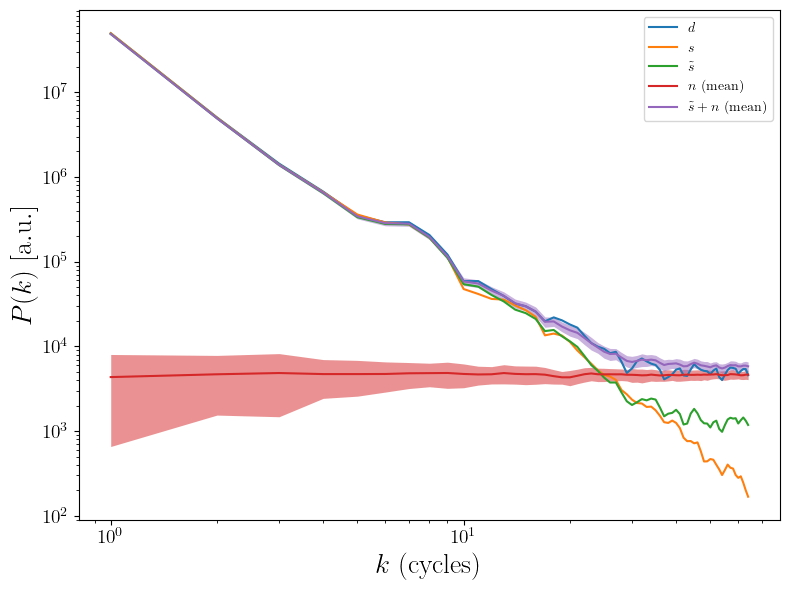

In [45]:
x1, x2, x3 = data_nu2[0], dust_nu2[0], result_nu2[0]
fields = [x1,x2,x3, contamination_arr_nu2.squeeze(), result_nu2[0] + contamination_arr_nu2.squeeze()]
titles = [r"$d$", r"$s$", r"$\tilde{s}$", r"$n$",  r"$\tilde{s} + n$"]

plot_PS(fields, titles=titles, fname='PS.png')